# CCE Moorings and MITgcm - Regional Temporal Scales Analysis   

**Purpose**: Code for comparing the CCE mooring scale analysis with the profile time series from the MITgcm model.

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook: 

In [1]:
%matplotlib inline

Import python libraries

In [2]:
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
from netCDF4 import Dataset, num2date
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import cmocean
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.lines as mlines
import glob
from matplotlib.ticker import LogLocator

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
import cartopy_figs as cart

In [3]:
def add_corner_label(ax, pos, label, fontsize=12):
    
    # Place text in lower left corner inside the axes
    ax.text(
        pos[0], pos[1], label,
        transform=ax.transAxes,
        fontsize=fontsize,
        fontweight='normal',
        va='top', ha='left',
        bbox=dict(
            boxstyle='square,pad=0.3',
            facecolor=(1, 1, 1, 0.6),  # faded white fill with alpha=0.6
            edgecolor='black',
            linewidth=1
        )
    )

Set data analysis parameters

In [4]:
# Set processing parameters
option_plot          = 0      # Specifies if supplementary plots are plotted

# Set space parameters
lat_bnds     = [33, 35]                      # Specifies the latitude bounds for the region to analyze
lon_bnds     = [-123 % 360, -120 % 360]      # Specifies the longitude bounds for the region to analyze

# Set path to project directory
PATH = "/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/AirSeaCoupling"
PATH_bathy  = ROOT + 'AirSeaCoupling/data/bathymetry/'

# Set plotting parameters 
depth_lim = [0,200]
option_data = 'model'
option_log = 0 
fontsize = 14
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
    "text.usetex": True,           # Use LaTeX for all text
    "font.family": "serif",        # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
})

Load CCE intermediate data and mitgcm time scale analysis data

In [5]:
#-------------------------------------------------------#
# MITgcm Data
#-------------------------------------------------------#
ROOT_mitgcm   = "/data/mitgcm/SWOT_MARA_RUN4_LY/spatial"
filename_rho  = glob.glob(PATH + ROOT_mitgcm + "/mitgcm_regional_temporal_scale_density_depth_*m.npz")
filename_u    = glob.glob(PATH + ROOT_mitgcm + "/mitgcm_regional_temporal_scale_uvel_depth_*m.npz")
filename_v    = glob.glob(PATH + ROOT_mitgcm + "/mitgcm_regional_temporal_scale_vvel_depth_*m.npz")

#--- Potential Density ---# 

# Set array 
Lt_rho      = []
depth_rho_m = []

# Set counter 
cn = 0

# Loop through files
for f in filename_rho:

    # Load data 
    ds_rho   = np.load(f, allow_pickle=True)

    # Extract decorrelation scales and depth level
    Lt_rho.append(ds_rho["Lt_days"])   # Units: days
    depth_rho_m.append(np.abs(ds_rho['depth']))

    # Extract coordinates
    if cn == 0:
        lon_rho_m = ds_rho["lon"]
        lat_rho_m = ds_rho["lat"]

    # Reset counter 
    cn += 1

#--- Along-shore Velocity ---# 

# Set array 
Lt_u      = []
depth_u_m = []

# Set counter 
cn = 0

# Loop through files
for f in filename_u:

    # Load data 
    ds_u = np.load(f, allow_pickle=True)

    # Extract decorrelation scales and depth level
    Lt_u.append(ds_u["Lt_days"])             # Units: days
    depth_u_m.append(np.abs(ds_u['depth']))

    # Extract coordinates
    if cn == 0:
        lon_u_m = ds_u["lon"]
        lat_u_m = ds_u["lat"]

    # Reset counter 
    cn += 1

#--- Cross-shore Velocity ---# 

# Set array 
Lt_v      = []
depth_v_m = []

# Set counter 
cn = 0

# Loop through files
for f in filename_v:

    # Load data 
    ds_v = np.load(f, allow_pickle=True)

    # Extract decorrelation scales and depth levels
    Lt_v.append(ds_v["Lt_days"])            # Units: days
    depth_v_m.append(np.abs(ds_v['depth']))

    # Extract coordinates
    if cn == 0:
        lon_v_m = ds_v["lon"]
        lat_v_m = ds_v["lat"]

    # Reset counter 
    cn += 1

#-------------------------------------------------------#
# CCE Scale Analysis Data
#-------------------------------------------------------#
filename_CCE1_CTD = glob.glob(PATH + "/data/CCE/CCE1/CTD/CCE1_CTD_*_scale_data_gridded.npz")
filename_CCE2_CTD = glob.glob(PATH + "/data/CCE/CCE2/CTD/CCE2_CTD_*_scale_data_gridded.npz")
filename_CCE1_ADCP = glob.glob(PATH + "/data/CCE/CCE1/ADCP/CCE1_ADCP_*_scale_data.npz")
filename_CCE2_ADCP = glob.glob(PATH + "/data/CCE/CCE2/ADCP/CCE2_ADCP_*_scale_data.npz")

# Load data 
ds_CCE1_CTD    = np.load(filename_CCE1_CTD[0], allow_pickle=True)
ds_CCE2_CTD    = np.load(filename_CCE2_CTD[0], allow_pickle=True)

ds_CCE1_ADCP   = np.load(filename_CCE1_ADCP[0], allow_pickle=True)
ds_CCE2_ADCP   = np.load(filename_CCE2_ADCP[0], allow_pickle=True)

# Extract data variables

#--- CCE1 ---# 
lon1             = ds_CCE1_CTD["lon"] %360
lat1             = ds_CCE1_CTD["lat"]
depth1           = ds_CCE1_CTD["depth"]
depth1_adcp      = ds_CCE1_ADCP["depth"]

Lt1_rho          = ds_CCE1_CTD["Lt_rho"]      # Units: days
Lt1_u            = ds_CCE1_ADCP["Lt_u"]      
Lt1_v            = ds_CCE1_ADCP["Lt_v"]

meanRho1         = ds_CCE1_CTD["meanRho_profile"]  
stdmRho1         = ds_CCE1_CTD["stdmRho_profile"] 

meanU1         = ds_CCE1_ADCP["meanU_profile"] 
meanV1         = ds_CCE1_ADCP["meanV_profile"] 
stdmU1         = ds_CCE1_ADCP["stdmU_profile"] 
stdmV1         = ds_CCE1_ADCP["stdmV_profile"] 

#--- CCE2 ---# 
lon2             = ds_CCE2_CTD["lon"] %360
lat2             = ds_CCE2_CTD["lat"]
depth2           = ds_CCE2_CTD["depth"]
depth2_adcp      = ds_CCE2_ADCP["depth"]

Lt2_rho          = ds_CCE2_CTD["Lt_rho"]      # Units: days
Lt2_u            = ds_CCE2_ADCP["Lt_u"]        
Lt2_v            = ds_CCE2_ADCP["Lt_v"]

meanRho2         = ds_CCE2_CTD["meanRho_profile"] 
stdmRho2         = ds_CCE2_CTD["stdmRho_profile"] 

meanU2         = ds_CCE2_ADCP["meanU_profile"] 
meanV2         = ds_CCE2_ADCP["meanV_profile"] 
stdmU2         = ds_CCE2_ADCP["stdmU_profile"] 
stdmV2         = ds_CCE2_ADCP["stdmV_profile"] 

Read in bathymetry data

In [6]:
# Load bathymetry data 
filename = PATH_bathy + "topo_25.1.nc"
ds_bathy = xr.open_dataset(filename, engine="netcdf4")

# Extract data variables
lon_b = ds_bathy["lon"]  # Longitude
lat_b = ds_bathy["lat"]  # Latitude
bathy = ds_bathy["z"]    # Elevation/Bathymetry

# Convert convesion of longitude (neg from the prime meridian to positive definite wrapping around the earth)
lon_n = lon_b % 360

# Set max and min values 
lon_min = lon_bnds[0]
lon_max = lon_bnds[1]
lat_min = lat_bnds[0]
lat_max = lat_bnds[1]

# Extract data from bathymetry 
lon_grid = lon_n[(lon_n >= lon_min) & (lon_n <= lon_max)]
lat_grid = lat_b[(lat_b >= lat_min) & (lat_b <= lat_max)]
bathy_grid   = bathy[(lat_b >= lat_min) & (lat_b <= lat_max),(lon_n >= lon_min) & (lon_n <= lon_max)]

In [7]:
def set_subplots(ax, projection, resolution, lon_min, lon_max, lat_min, lat_max):

    """
    set_subplots(ax, projection)

        Function for placing x and y axes labels for longitude and latitude respectively

        Parameters
        ----------
        ax : geospatial axes for the subplot (cartopy object)
            ex: fig, axes = plt.subplots(3, 2, figsize=(16,12), subplot_kw={'projection': projection})
                ax1, ax2, ax3, ax4, ax5, ax6 = axes.flatten()
                ax = ax1 or ax2 or ...
        projection : cartopy map projection. Example: ccrs.PlateCarree(central_longitude=0.0) 
        resolution : specifies the resolution of the coastline map. Options include: '110m', '50m', '10m'
        lon_min : minimum extent for longitude on the scale from -180 to 179
            ex: lon_min = -180
        lon_max : maximum extent for longitude on the scale from -180 to 179
            ex: lon_max = 179
        lat_min : minimum extent for latitude on the scale from -90 to 89
            ex: lat_min = -66
        lat_max : maximum extent for latitude on the scale from -90 to 89
            ex: lat_max = 66

        Returns
        -------
        No objects returned. A geospatial map with desired longitude and latitude extent with coastlines and land.

        Libraries necessary to run function
        -----------------------------------
        import cartopy.feature as cfeature

    """
    # import libraries
    import cartopy.feature as cfeature

    # Set extents of map
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], projection)

    # Plot coastlines and land
    ax.coastlines(resolution=resolution)
    ax.add_feature(
        cfeature.NaturalEarthFeature("physical", "land", resolution, facecolor="Gray")
    )

    return

Plot the decorrelation scales

In [9]:
def plot_regional_decor(ax,data,lon_grid,lat_grid,bathy_grid,projection,resolution,lon_min,lon_max,lat_min,
                        lat_max,cmap,levels,xticks,yticks,fontsize,vmin,vmax,lon1,lat1,lon2,lat2,norm,Lt1,Lt2,
                        option_cce,option_cce_label): 

    '''
    
    '''

    # Set figure axes 
    set_subplots(ax, projection, resolution, lon_min=lon_min, lon_max=lon_max, lat_min=lat_min, lat_max=lat_max) 

    # Plot decorrelation scale
    cf = ax.contourf(
                    lon_rho_m, lat_rho_m, data, levels=levels, 
                    transform=ccrs.PlateCarree(),
                    cmap=cmap,  
                    shading="auto", 
                    extend='both',
                    vmin=vmin, vmax=vmax
                    )

    if option_cce == 1: 

        #--- CCE1 ---# 

        # Plot the mooring point with matching color
        ax.scatter(
            lon1, lat1, 
            color=cmocean.cm.amp(norm(Lt1)),  # color from the same colormap
            edgecolor='black', marker='^', s=70,  # customize as needed
            linewidth=0.5,
            transform=ccrs.PlateCarree(),
            zorder=10,
            label='Mooring'
        )

        if option_cce_label == 1:

            # Add a label next to the mooring marker
            ax.text(
                lon1 - 0.065, lat1 + 0.08,           # Slight offset to avoid overlapping the point
                f"CCE1",                # Text label showing decorrelation scale in months
                transform=ccrs.PlateCarree(),
                fontsize=fontsize-5,
                fontweight='bold',
                color='black',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1.5, alpha=0.5),
                zorder=11
            )

        #--- CCE2 ---# 

        # Plot the mooring point with matching color
        ax.scatter(
            lon2, lat2, 
            color=cmocean.cm.amp(norm(Lt2)),  # color from the same colormap
            edgecolor='black', marker='^', s=70,  # customize as needed
            linewidth=0.5,
            transform=ccrs.PlateCarree(),
            zorder=10,
            label='Mooring'
        )

        if option_cce_label == 1:

            # Add a label next to the mooring marker
            ax.text(
                lon2 - 0.065, lat2 + 0.08,           # Slight offset to avoid overlapping the point
                f"CCE2",                
                transform=ccrs.PlateCarree(),
                fontsize=fontsize-5,
                fontweight='bold',
                color='black',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1.5, alpha=0.5),
                zorder=11
            )
    
    # Plot depth contour lines
    level_innershelf = np.arange(0,300,100)
    levels_midshelf = np.arange(1000,3000,500)
    contour1 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=levels_midshelf, colors='black', linewidths=0.5, linestyles='dashed')
    contour2 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[2000], colors='black', linewidths=1, linestyles='solid')
    contour3 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=level_innershelf, colors='black', linewidths=0.5, linestyles='dashed')
    contour4 = ax.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[200], colors='black', linewidths=1, linestyles='solid')
    plt.clabel(contour1, fontsize=6)
    plt.clabel(contour2, fontsize=6)
    plt.clabel(contour3, fontsize=6)
    plt.clabel(contour4, fontsize=6)
    
    # Set grid ticks 
    cart.set_grid_ticks(
        ax,
        projection=ccrs.PlateCarree(),
        xticks=xticks,
        yticks=yticks,
        xlabels=True,
        ylabels=True,
        grid=True,
        fontsize=fontsize,
        color="black",
    )

    return cf
    


/Users/lukecolosi/opt/anaconda3/envs/airsea_coupling/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1655: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)
/Users/lukecolosi/opt/anaconda3/envs/airsea_coupling/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1655: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)
/Users/lukecolosi/opt/anaconda3/envs/airsea_coupling/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1655: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)
/Users/lukecolosi/opt/anaconda3/envs/airsea_coupling/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1655: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)
/Users/lukecolosi/opt/anaconda3/envs/airsea_coupling/lib/python3.12/site-packages/cartopy/mpl/ge

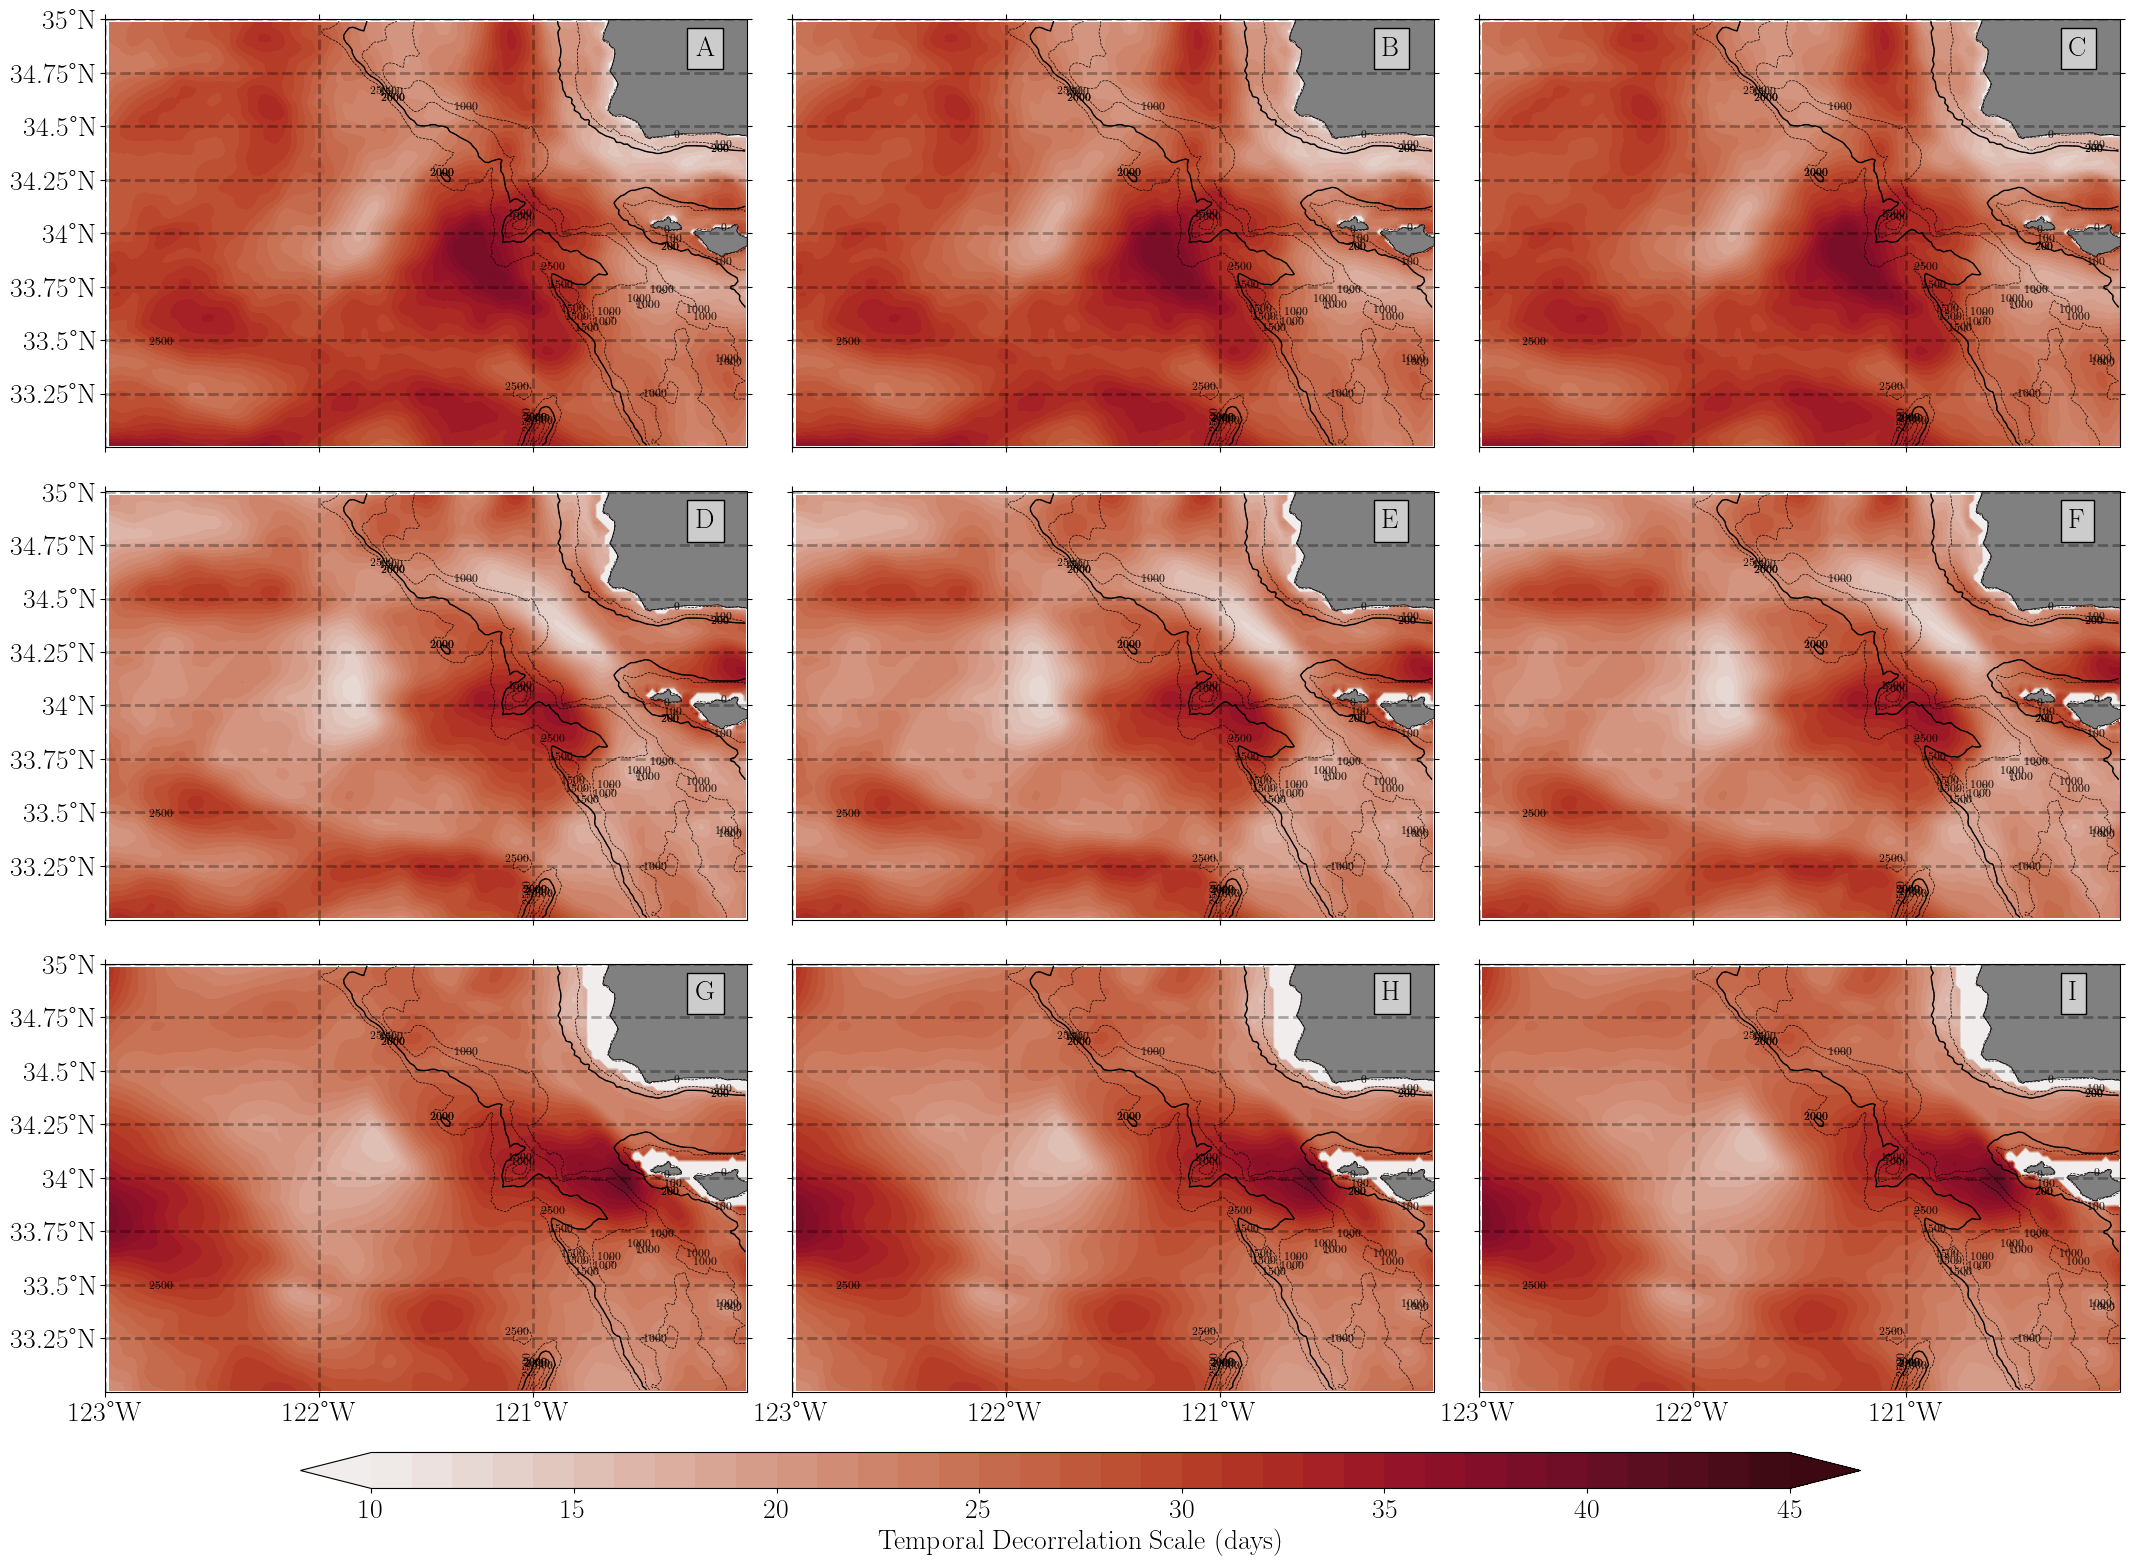

In [ ]:
# Set plotting parameters
projection = ccrs.PlateCarree(central_longitude=0.0)
xticks = [-123, -122, -121]
yticks = [33.25, 33.50, 33.75, 34.00, 34.25, 34.50, 34.75, 35.00]
resolution = "10m"
bounds = np.arange(0,360+40,40)
lon_min = -123 
lon_max = -120
lat_min = 33
lat_max = 35
cmap = cmocean.cm.amp
label = r'Temporal Decorrelation Scale (days)'
levels = np.arange(10,45+1,1) 
fontsize = 20

# Create figure
fig, axes = plt.subplots(3,3, figsize=(26, 18), subplot_kw={"projection": projection})
ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8,ax9 = axes.flatten()

plt.subplots_adjust(hspace=0.07, wspace=0.07)

#--- Subplot 1 ---# 
cf = plot_regional_decor(ax1,Lt_rho[2],lon_grid,lat_grid,bathy_grid,projection,resolution,lon_min,lon_max,lat_min,lat_max,cmap,levels,xticks,yticks,fontsize)

# Set tick parameters
ax1.tick_params(top=True, bottom=True, left=True, right=True, labelright=False, labelleft=True, labelbottom=False, labeltop=False,
                direction='out', which='both', length=3.5)

#--- Subplot 2 ---# 
_ = plot_regional_decor(ax4,Lt_rho[1],lon_grid,lat_grid,bathy_grid,projection,resolution,lon_min,lon_max,lat_min,lat_max,cmap,levels,xticks,yticks,fontsize)

# Set tick parameters
ax4.tick_params(top=True, bottom=True, left=True, right=True, labelright=False, labelleft=True, labelbottom=False, labeltop=False,
                direction='out', which='both', length=3.5)

#--- Subplot 3 ---# 
_ = plot_regional_decor(ax7,Lt_rho[0],lon_grid,lat_grid,bathy_grid,projection,resolution,lon_min,lon_max,lat_min,lat_max,cmap,levels,xticks,yticks,fontsize)

# Set tick parameters
ax7.tick_params(top=True, bottom=True, left=True, right=True, labelright=False, labelleft=True, labelbottom=True, labeltop=False,
                direction='out', which='both', length=3.5)

#--- Subplot 4 ---# 
_ = plot_regional_decor(ax2,Lt_rho[2],lon_grid,lat_grid,bathy_grid,projection,resolution,lon_min,lon_max,lat_min,lat_max,cmap,levels,xticks,yticks,fontsize)

# Set tick parameters
ax2.tick_params(top=True, bottom=True, left=True, right=True, labelright=False, labelleft=False, labelbottom=False, labeltop=False,
                direction='out', which='both', length=3.5)

#--- Subplot 5 ---# 
_ = plot_regional_decor(ax5,Lt_rho[1],lon_grid,lat_grid,bathy_grid,projection,resolution,lon_min,lon_max,lat_min,lat_max,cmap,levels,xticks,yticks,fontsize)

# Set tick parameters
ax5.tick_params(top=True, bottom=True, left=True, right=True, labelright=False, labelleft=False, labelbottom=False, labeltop=False,
                direction='out', which='both', length=3.5)

#--- Subplot 6 ---# 
_ = plot_regional_decor(ax8,Lt_rho[0],lon_grid,lat_grid,bathy_grid,projection,resolution,lon_min,lon_max,lat_min,lat_max,cmap,levels,xticks,yticks,fontsize)

# Set tick parameters
ax8.tick_params(top=True, bottom=True, left=True, right=True, labelright=False, labelleft=False, labelbottom=True, labeltop=False,
                direction='out', which='both', length=3.5)

#--- Subplot 7 ---# 
_ = plot_regional_decor(ax3,Lt_rho[2],lon_grid,lat_grid,bathy_grid,projection,resolution,lon_min,lon_max,lat_min,lat_max,cmap,levels,xticks,yticks,fontsize)

# Set tick parameters
ax3.tick_params(top=True, bottom=True, left=True, right=True, labelright=False, labelleft=False, labelbottom=False, labeltop=False,
                direction='out', which='both', length=3.5)

#--- Subplot 8 ---# 
_ = plot_regional_decor(ax6,Lt_rho[1],lon_grid,lat_grid,bathy_grid,projection,resolution,lon_min,lon_max,lat_min,lat_max,cmap,levels,xticks,yticks,fontsize)

# Set tick parameters
ax6.tick_params(top=True, bottom=True, left=True, right=True, labelright=False, labelleft=False, labelbottom=False, labeltop=False,
                direction='out', which='both', length=3.5)

#--- Subplot 9 ---# 
_ = plot_regional_decor(ax9,Lt_rho[0],lon_grid,lat_grid,bathy_grid,projection,resolution,lon_min,lon_max,lat_min,lat_max,cmap,levels,xticks,yticks,fontsize)

# Set tick parameters
ax9.tick_params(top=True, bottom=True, left=True, right=True, labelright=False, labelleft=False, labelbottom=True, labeltop=False,
                direction='out', which='both', length=3.5)

# Set color bar
cax = fig.add_axes([0.20, 0.06, 0.6, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='horizontal', extend='both') 
cbar.set_label(label, fontsize=fontsize)
cbar.set_ticks(np.arange(10,45+5,5),labels=np.arange(10,45+5,5),fontsize=fontsize)

# Label each subplot
pos = [0.92, 0.96]
add_corner_label(ax1, pos, 'A', fontsize = fontsize)
add_corner_label(ax2, pos, 'B', fontsize = fontsize)
add_corner_label(ax3, pos, 'C', fontsize = fontsize)
add_corner_label(ax4, pos, 'D', fontsize = fontsize)
add_corner_label(ax5, pos, 'E', fontsize = fontsize)
add_corner_label(ax6, pos, 'F', fontsize = fontsize)
add_corner_label(ax7, pos, 'G', fontsize = fontsize)
add_corner_label(ax8, pos, 'H', fontsize = fontsize)
add_corner_label(ax9, pos, 'I', fontsize = fontsize)

# Show the plot
plt.show()

/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)
/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)
/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)


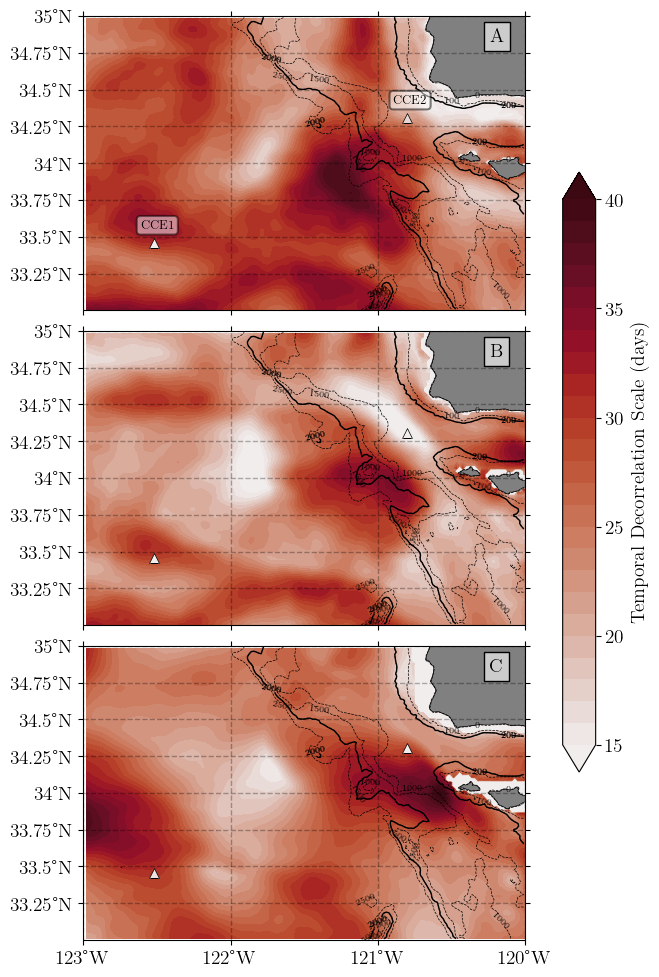

In [9]:
# Set plotting parameters
projection = ccrs.PlateCarree(central_longitude=0.0)
xticks = [-123, -122, -121, -120]
yticks = [33.25, 33.50, 33.75, 34.00, 34.25, 34.50, 34.75, 35.00]
resolution = "10m"
bounds = np.arange(0,360+40,40)
lon_min = -123 
lon_max = -120
lat_min = 33
lat_max = 35
cmap = cmocean.cm.amp
label = r'Temporal Decorrelation Scale (days)'
vmin = 15
vmax = 40
levels = np.arange(vmin,vmax+1,1) 
levels_labels = np.arange(vmin,vmax+5,5) 
fontsize = 14
option_cce = 1

# Define the same normalization used for the contourf plot
norm = mcolors.Normalize(vmin=levels.min(), vmax=levels.max())

# Create figure
fig, axes = plt.subplots(3,1, figsize=(22, 12), subplot_kw={"projection": projection})
ax1,ax2,ax3 = axes.flatten()

#--- Subplot 1 ---# 
idx = np.argmin(abs(depth1 - depth_rho_m[2]))
cf = plot_regional_decor(ax1,Lt_rho[2],lon_grid,lat_grid,bathy_grid,projection,resolution,lon_min,lon_max,lat_min,
                         lat_max,cmap,levels,xticks,yticks,fontsize,vmin,vmax,lon1,lat1,lon2,lat2,norm,
                         Lt1_rho[idx],Lt2_rho[idx],option_cce,option_cce_label=1)

# Set tick parameters
ax1.tick_params(top=True, bottom=True, left=True, right=True, labelright=False, labelleft=True, labelbottom=False, labeltop=False,
                direction='out', which='both', length=3.5)
ax1.grid(linewidth=1, color='k', alpha=0.3, linestyle="--")

#--- Subplot 2 ---# 
idx = np.argmin(abs(depth1 - depth_rho_m[1]))
_ = plot_regional_decor(ax2,Lt_rho[1],lon_grid,lat_grid,bathy_grid,projection,resolution,lon_min,lon_max,lat_min,
                        lat_max,cmap,levels,xticks,yticks,fontsize,vmin,vmax,lon1,lat1,lon2,lat2,norm,
                         Lt1_rho[idx],Lt2_rho[idx],option_cce,option_cce_label=0)

# Set tick parameters
ax2.tick_params(top=True, bottom=True, left=True, right=True, labelright=False, labelleft=True, labelbottom=False, labeltop=False,
                direction='out', which='both', length=3.5)
ax2.grid(linewidth=1, color='k', alpha=0.3, linestyle="--")

#--- Subplot 3 ---# 
idx = np.argmin(abs(depth1 - depth_rho_m[0]))
_ = plot_regional_decor(ax3,Lt_rho[0],lon_grid,lat_grid,bathy_grid,projection,resolution,lon_min,lon_max,lat_min,
                        lat_max,cmap,levels,xticks,yticks,fontsize,vmin,vmax,lon1,lat1,lon2,lat2,norm,
                         Lt1_rho[idx],Lt2_rho[idx],option_cce,option_cce_label=0)

# Set tick parameters
ax3.tick_params(top=True, bottom=True, left=True, right=True, labelright=False, labelleft=True, labelbottom=True, labeltop=False,
                direction='out', which='both', length=3.5)
ax3.grid(linewidth=1, color='k', alpha=0.3, linestyle="--")

# Set color bar
cax = fig.add_axes([0.63, 0.25, 0.015, 0.5])  # [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(label, fontsize=fontsize)
cbar.set_ticks(levels_labels,labels=levels_labels,fontsize=fontsize)

# Label each subplot
pos = [0.92, 0.96]
add_corner_label(ax1, pos, 'A', fontsize = fontsize)
add_corner_label(ax2, pos, 'B', fontsize = fontsize)
add_corner_label(ax3, pos, 'C', fontsize = fontsize)

# Show the plot
plt.subplots_adjust(hspace=0.07, wspace=0.07)
plt.show()

In [18]:
depth_v_m

[np.float32(77.965), np.float32(29.345), np.float32(9.66)]

/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)


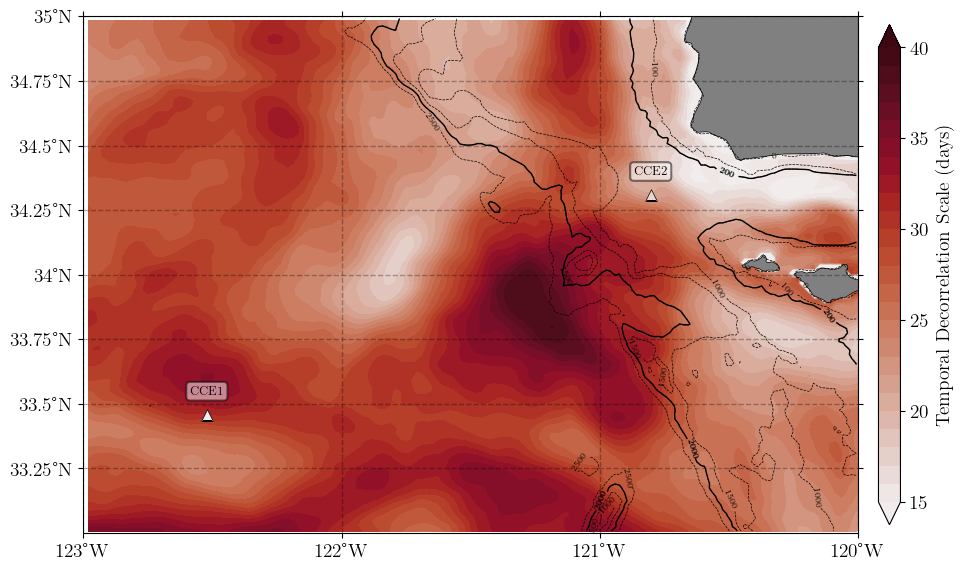

In [11]:
# Set plotting parameters
projection = ccrs.PlateCarree(central_longitude=0.0)
xticks = [-123, -122, -121, -120]
yticks = [33.25, 33.50, 33.75, 34.00, 34.25, 34.50, 34.75, 35.00]
resolution = "10m"
bounds = np.arange(0,360+40,40)
lon_min = -123 
lon_max = -120
lat_min = 33
lat_max = 35
cmap = cmocean.cm.amp
label = r'Temporal Decorrelation Scale (days)'
vmin = 15
vmax = 40
levels = np.arange(vmin,vmax+1,1) 
levels_labels = np.arange(vmin,vmax+5,5) 
fontsize = 14
option_cce = 1

# Define the same normalization used for the contourf plot
norm = mcolors.Normalize(vmin=levels.min(), vmax=levels.max())

# Create figure
fig, axes = plt.subplots(1,1, figsize=(10, 10), subplot_kw={"projection": projection})

#--- Subplot 1 ---# 
idx = np.argmin(abs(depth1 - depth_rho_m[2]))
cf = plot_regional_decor(axes,Lt_rho[2],lon_grid,lat_grid,bathy_grid,projection,resolution,lon_min,lon_max,lat_min,
                         lat_max,cmap,levels,xticks,yticks,fontsize,vmin,vmax,lon1,lat1,lon2,lat2,norm,
                         Lt1_rho[idx],Lt2_rho[idx],option_cce,option_cce_label=1)

# Set tick parameters
axes.tick_params(top=True, bottom=True, left=True, right=True, labelright=False, labelleft=True, labelbottom=True, labeltop=False,
                direction='out', which='both', length=3.5)
axes.grid(linewidth=1, color='k', alpha=0.3, linestyle="--")

# Set color bar
cax = fig.add_axes([0.92, 0.245, 0.022, 0.5])  # [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(label, fontsize=fontsize)
cbar.set_ticks(levels_labels,labels=levels_labels,fontsize=fontsize)


/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)


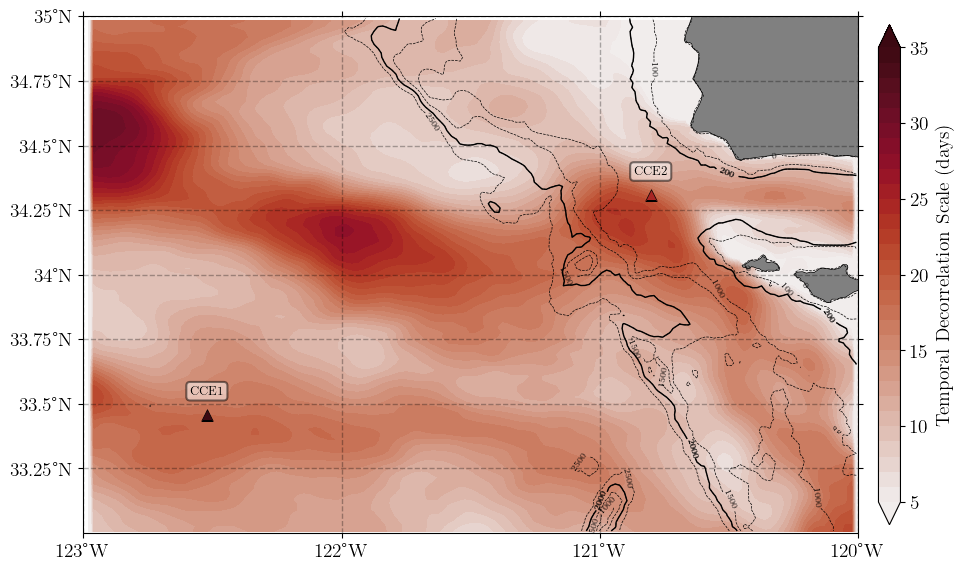

In [14]:
# Set plotting parameters
projection = ccrs.PlateCarree(central_longitude=0.0)
xticks = [-123, -122, -121, -120]
yticks = [33.25, 33.50, 33.75, 34.00, 34.25, 34.50, 34.75, 35.00]
resolution = "10m"
bounds = np.arange(0,360+40,40)
lon_min = -123 
lon_max = -120
lat_min = 33
lat_max = 35
cmap = cmocean.cm.amp
label = r'Temporal Decorrelation Scale (days)'
vmin = 5
vmax = 35
levels = np.arange(vmin,vmax+1,1) 
levels_labels = np.arange(vmin,vmax+5,5) 
fontsize = 14
option_cce = 1

# Define the same normalization used for the contourf plot
norm = mcolors.Normalize(vmin=levels.min(), vmax=levels.max())

# Create figure
fig, axes = plt.subplots(1,1, figsize=(10, 10), subplot_kw={"projection": projection})

#--- Subplot 1 ---# 
idx = np.argmin(abs(depth1 - depth_u_m[0]))
cf = plot_regional_decor(axes,Lt_u[0],lon_grid,lat_grid,bathy_grid,projection,resolution,lon_min,lon_max,lat_min,
                         lat_max,cmap,levels,xticks,yticks,fontsize,vmin,vmax,lon1,lat1,lon2,lat2,norm,
                         Lt1_u[idx],Lt2_u[idx],option_cce,option_cce_label=1)

# Set tick parameters
axes.tick_params(top=True, bottom=True, left=True, right=True, labelright=False, labelleft=True, labelbottom=True, labeltop=False,
                direction='out', which='both', length=3.5)
axes.grid(linewidth=1, color='k', alpha=0.3, linestyle="--")

# Set color bar
cax = fig.add_axes([0.92, 0.245, 0.022, 0.5])  # [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(label, fontsize=fontsize)
cbar.set_ticks(levels_labels,labels=levels_labels,fontsize=fontsize)


/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)


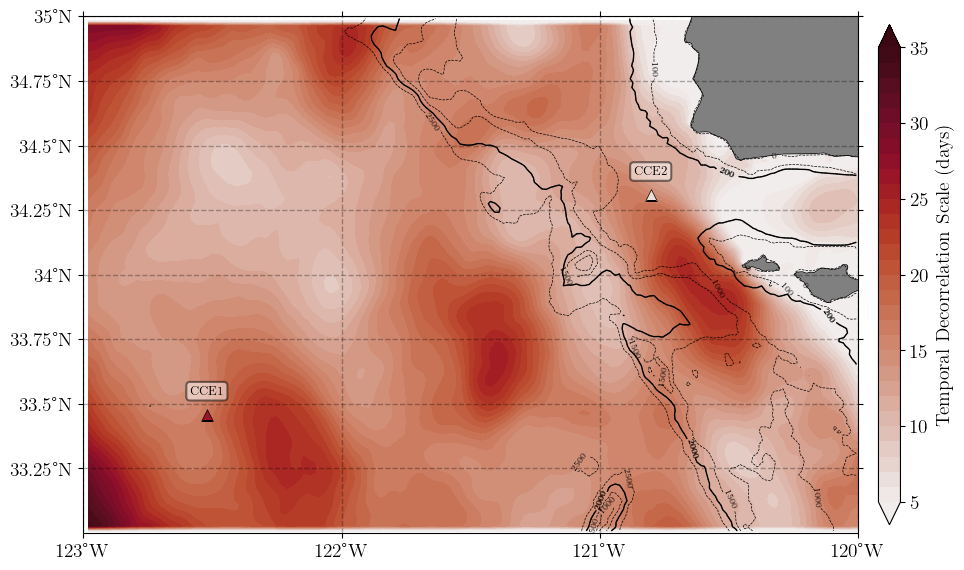

In [19]:
# Set plotting parameters
projection = ccrs.PlateCarree(central_longitude=0.0)
xticks = [-123, -122, -121, -120]
yticks = [33.25, 33.50, 33.75, 34.00, 34.25, 34.50, 34.75, 35.00]
resolution = "10m"
bounds = np.arange(0,360+40,40)
lon_min = -123 
lon_max = -120
lat_min = 33
lat_max = 35
cmap = cmocean.cm.amp
label = r'Temporal Decorrelation Scale (days)'
vmin = 5
vmax = 35
levels = np.arange(vmin,vmax+1,1) 
levels_labels = np.arange(vmin,vmax+5,5) 
fontsize = 14
option_cce = 1

# Define the same normalization used for the contourf plot
norm = mcolors.Normalize(vmin=levels.min(), vmax=levels.max())

# Create figure
fig, axes = plt.subplots(1,1, figsize=(10, 10), subplot_kw={"projection": projection})

#--- Subplot 1 ---# 
idx = np.argmin(abs(depth1 - depth_v_m[2]))
cf = plot_regional_decor(axes,Lt_v[2],lon_grid,lat_grid,bathy_grid,projection,resolution,lon_min,lon_max,lat_min,
                         lat_max,cmap,levels,xticks,yticks,fontsize,vmin,vmax,lon1,lat1,lon2,lat2,norm,
                         Lt1_v[idx],Lt2_v[idx],option_cce,option_cce_label=1)

# Set tick parameters
axes.tick_params(top=True, bottom=True, left=True, right=True, labelright=False, labelleft=True, labelbottom=True, labeltop=False,
                direction='out', which='both', length=3.5)
axes.grid(linewidth=1, color='k', alpha=0.3, linestyle="--")

# Set color bar
cax = fig.add_axes([0.92, 0.245, 0.022, 0.5])  # [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(label, fontsize=fontsize)
cbar.set_ticks(levels_labels,labels=levels_labels,fontsize=fontsize)


/Users/lukecolosi/opt/anaconda3/envs/airsea_coupling/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1655: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)
/Users/lukecolosi/opt/anaconda3/envs/airsea_coupling/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1655: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)
/Users/lukecolosi/opt/anaconda3/envs/airsea_coupling/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1655: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)


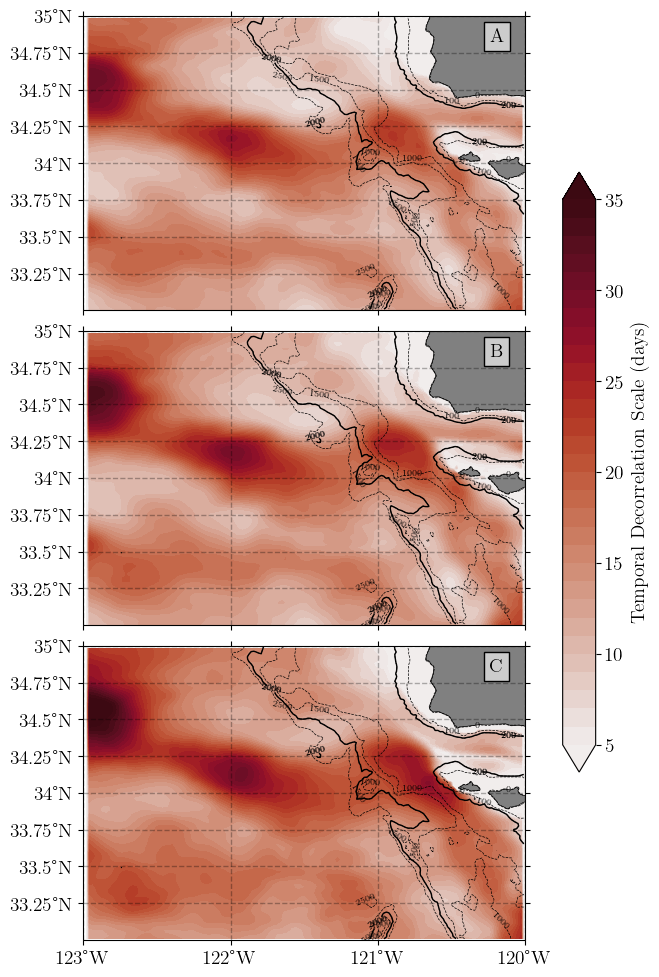

In [31]:
# Set plotting parameters
projection = ccrs.PlateCarree(central_longitude=0.0)
xticks = [-123, -122, -121, -120]
yticks = [33.25, 33.50, 33.75, 34.00, 34.25, 34.50, 34.75, 35.00]
resolution = "10m"
bounds = np.arange(0,360+40,40)
lon_min = -123 
lon_max = -120
lat_min = 33
lat_max = 35
cmap = cmocean.cm.amp
label = r'Temporal Decorrelation Scale (days)'
vmin = 5
vmax = 35
levels = np.arange(vmin,vmax+1,1) 
levels_labels = np.arange(vmin,vmax+5,5) 
fontsize = 14
option_cce = 0

# Define the same normalization used for the contourf plot
norm = mcolors.Normalize(vmin=levels.min(), vmax=levels.max())

# Create figure
fig, axes = plt.subplots(3,1, figsize=(22, 12), subplot_kw={"projection": projection})
ax1,ax2,ax3 = axes.flatten()

#--- Subplot 1 ---# 
idx = np.argmin(abs(depth1_adcp - depth_u_m[0]))
cf = plot_regional_decor(ax1,Lt_u[0],lon_grid,lat_grid,bathy_grid,projection,resolution,lon_min,lon_max,lat_min,
                         lat_max,cmap,levels,xticks,yticks,fontsize,vmin,vmax,lon1,lat1,lon2,lat2,norm,
                         Lt1_u[idx],Lt2_u[idx],option_cce,option_cce_label=1)

# Set tick parameters
ax1.tick_params(top=True, bottom=True, left=True, right=True, labelright=False, labelleft=True, labelbottom=False, labeltop=False,
                direction='out', which='both', length=3.5)
ax1.grid(linewidth=1, color='k', alpha=0.3, linestyle="--")

#--- Subplot 2 ---# 
idx = np.argmin(abs(depth1_adcp - depth_u_m[1]))
_ = plot_regional_decor(ax2,Lt_u[1],lon_grid,lat_grid,bathy_grid,projection,resolution,lon_min,lon_max,lat_min,
                        lat_max,cmap,levels,xticks,yticks,fontsize,vmin,vmax,lon1,lat1,lon2,lat2,norm,
                         Lt1_u[idx],Lt2_u[idx],option_cce,option_cce_label=0)

# Set tick parameters
ax2.tick_params(top=True, bottom=True, left=True, right=True, labelright=False, labelleft=True, labelbottom=False, labeltop=False,
                direction='out', which='both', length=3.5)
ax2.grid(linewidth=1, color='k', alpha=0.3, linestyle="--")

#--- Subplot 3 ---# 
idx = np.argmin(abs(depth1_adcp - depth_u_m[2]))
_ = plot_regional_decor(ax3,Lt_u[2],lon_grid,lat_grid,bathy_grid,projection,resolution,lon_min,lon_max,lat_min,
                        lat_max,cmap,levels,xticks,yticks,fontsize,vmin,vmax,lon1,lat1,lon2,lat2,norm,
                         Lt1_u[idx],Lt2_u[idx],option_cce,option_cce_label=0)

# Set tick parameters
ax3.tick_params(top=True, bottom=True, left=True, right=True, labelright=False, labelleft=True, labelbottom=True, labeltop=False,
                direction='out', which='both', length=3.5)
ax3.grid(linewidth=1, color='k', alpha=0.3, linestyle="--")

# Set color bar
cax = fig.add_axes([0.63, 0.25, 0.015, 0.5])  # [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(label, fontsize=fontsize)
cbar.set_ticks(levels_labels,labels=levels_labels,fontsize=fontsize)

# Label each subplot
pos = [0.92, 0.96]
add_corner_label(ax1, pos, 'A', fontsize = fontsize)
add_corner_label(ax2, pos, 'B', fontsize = fontsize)
add_corner_label(ax3, pos, 'C', fontsize = fontsize)

# Show the plot
plt.subplots_adjust(hspace=0.07, wspace=0.07)
plt.show()

/Users/lukecolosi/opt/anaconda3/envs/airsea_coupling/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1655: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)
/Users/lukecolosi/opt/anaconda3/envs/airsea_coupling/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1655: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)
/Users/lukecolosi/opt/anaconda3/envs/airsea_coupling/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1655: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)


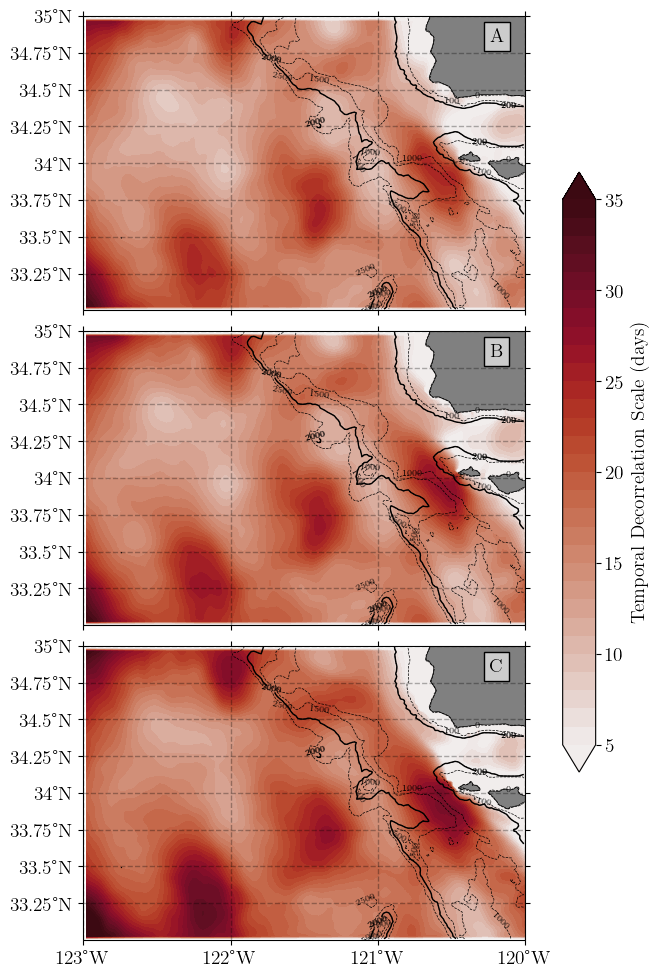

In [29]:
# Set plotting parameters
projection = ccrs.PlateCarree(central_longitude=0.0)
xticks = [-123, -122, -121, -120]
yticks = [33.25, 33.50, 33.75, 34.00, 34.25, 34.50, 34.75, 35.00]
resolution = "10m"
bounds = np.arange(0,360+40,40)
lon_min = -123 
lon_max = -120
lat_min = 33
lat_max = 35
cmap = cmocean.cm.amp
label = r'Temporal Decorrelation Scale (days)'
vmin = 5
vmax = 35
levels = np.arange(vmin,vmax+1,1) 
levels_labels = np.arange(vmin,vmax+5,5) 
fontsize = 14
option_cce = 0

# Define the same normalization used for the contourf plot
norm = mcolors.Normalize(vmin=levels.min(), vmax=levels.max())

# Create figure
fig, axes = plt.subplots(3,1, figsize=(22, 12), subplot_kw={"projection": projection})
ax1,ax2,ax3 = axes.flatten()

#--- Subplot 1 ---# 
idx = np.argmin(abs(depth1_adcp - depth_v_m[2]))
cf = plot_regional_decor(ax1,Lt_v[2],lon_grid,lat_grid,bathy_grid,projection,resolution,lon_min,lon_max,lat_min,
                         lat_max,cmap,levels,xticks,yticks,fontsize,vmin,vmax,lon1,lat1,lon2,lat2,norm,
                         Lt1_v[idx],Lt2_v[idx],option_cce,option_cce_label=1)

# Set tick parameters
ax1.tick_params(top=True, bottom=True, left=True, right=True, labelright=False, labelleft=True, labelbottom=False, labeltop=False,
                direction='out', which='both', length=3.5)
ax1.grid(linewidth=1, color='k', alpha=0.3, linestyle="--")

#--- Subplot 2 ---# 
idx = np.argmin(abs(depth1_adcp - depth_v_m[1]))
_ = plot_regional_decor(ax2,Lt_v[1],lon_grid,lat_grid,bathy_grid,projection,resolution,lon_min,lon_max,lat_min,
                        lat_max,cmap,levels,xticks,yticks,fontsize,vmin,vmax,lon1,lat1,lon2,lat2,norm,
                         Lt1_v[idx],Lt2_v[idx],option_cce,option_cce_label=0)

# Set tick parameters
ax2.tick_params(top=True, bottom=True, left=True, right=True, labelright=False, labelleft=True, labelbottom=False, labeltop=False,
                direction='out', which='both', length=3.5)
ax2.grid(linewidth=1, color='k', alpha=0.3, linestyle="--")

#--- Subplot 3 ---# 
idx = np.argmin(abs(depth1_adcp - depth_v_m[0]))
_ = plot_regional_decor(ax3,Lt_v[0],lon_grid,lat_grid,bathy_grid,projection,resolution,lon_min,lon_max,lat_min,
                        lat_max,cmap,levels,xticks,yticks,fontsize,vmin,vmax,lon1,lat1,lon2,lat2,norm,
                         Lt1_v[idx],Lt2_v[idx],option_cce,option_cce_label=0)

# Set tick parameters
ax3.tick_params(top=True, bottom=True, left=True, right=True, labelright=False, labelleft=True, labelbottom=True, labeltop=False,
                direction='out', which='both', length=3.5)
ax3.grid(linewidth=1, color='k', alpha=0.3, linestyle="--")

# Set color bar
cax = fig.add_axes([0.63, 0.25, 0.015, 0.5])  # [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both') 
cbar.set_label(label, fontsize=fontsize)
cbar.set_ticks(levels_labels,labels=levels_labels,fontsize=fontsize)

# Label each subplot
pos = [0.92, 0.96]
add_corner_label(ax1, pos, 'A', fontsize = fontsize)
add_corner_label(ax2, pos, 'B', fontsize = fontsize)
add_corner_label(ax3, pos, 'C', fontsize = fontsize)

# Show the plot
plt.subplots_adjust(hspace=0.07, wspace=0.07)
plt.show()